# U.S. Grocery Supply Chain: Sourcing Volatility, Inflation Velocity, and Retail Pricing (2016 – Present)

## Macro Food Commodity Pipeline: Wholesale Pressures vs. Consumer Index Shifts

### Description

This notebook provides a data-driven, multi-tiered pipeline visualization of the U.S. agricultural and retail grocery landscape. Utilizing series data directly from the Federal Reserve Economic Data (FRED), this project maps the pricing transmission sequence across three core categories (Meats, Coffee, and Produce/Staples) to analyze and cross-reference:

- **Wholesale Sourcing Inputs (PPI Series):** Raw commodity costs tracing structural upstream supplier pricing (e.g., *Slaughter Livestock*, *Unroasted Coffee*, *Milled Rice*).
- **Core Consumer Benchmarks (CPI Series):** Sub-category indices tracking retail inflation pressures, smoothed via both **3-Month Moving Averages (Index Trend)** and **12-Month Moving Averages (Long-Term Structural Baseline)**.
- **Inflation Velocity Tracker:** Year-over-Year (YoY) percentage calculation rates and corresponding **3-Month YoY Moving Averages** to highlight rapid short-term momentum or directional turning points.
- **Physical Checkout Pricing ($/lb or Dozen):** 12 specific high-volume grocery item retail costs, mapped concurrently on dual-axis scales to evaluate margin elasticity.

The analysis tracks the structural lags, margin expansions, and friction points as price shocks migrate from farm and roasting plant floors to domestic supermarket shelves.

---

## Objectives

- **Map Sourcing Transmission Gaps:** Identify structural lag timelines between wholesale producer spikes (PPI) and matching consumer benchmarks (CPI).
- **Analyze Price Elasticity across Food Families:** Evaluate how premium protein price ceilings react compared to inelastic baseline carbohydrates and staples.
- **Quantify Short-Term Inflation Velocity:** Utilize 3-Month Moving Averages of YoY inflation changes to capture real-time momentum spikes before long-term trend lines shift.
- **Establish a Single Retail Baseline:** Consolidate multiple retail items onto a standardized USD scale to compare historical pricing ranges from 2016 through the present day.

---

## Data Sources & Variable Dictionary

All analytical inputs are retrieved directly from the Federal Reserve Economic Data (FRED) engine:

### 1. Consumer Shelf Pricing Metrics (USD per Unit)
- **Beef & Pork Matrix:** `APU0000FC3101` (Beef Steaks), `APU0000FC1101` (Ground Beef), `APU0000FD3101` (Pork Chops), `APU0000FD4101` (Other Pork), `APU0000704111` (Sliced Bacon)
- **Poultry & Staples:** `APU0000FF1101` (Chicken Breast), `APU0000706111` (Whole Chicken), `APU0000708111` (Grade A Large Eggs)
- **Coffee & Grocery Staples:** `APU0000717311` (Ground Roast Coffee), `APU0000701312` (White Long-Grain Rice)
- **Produce:** `APU0000712311` (Field-Grown Tomatoes), `APU0000711211` (Bananas)

### 2. Macro Consumer Price Indices (CPI-U)
- `CUSR0000SAF112`: CPI for Meats, Poultry, Fish, and Eggs (Monthly Average Index)
- `CUSR0000SEFP01`: CPI for Coffee (Monthly Average Index)
- `CUSR0000SAF113`: CPI for Fruits and Vegetables (Monthly Average Index)

### 3. Wholesale Producer Price Commodities (PPI)
- `WPS022`: PPI for Processed Foods and Feeds: Meats, Poultry, and Fish
- `WPU026301`: PPI for Processed Foods and Feeds: Coffee (Whole Bean, Ground, Instant)
- `WPU0213`: PPI for Processed Foods and Feeds: Milled Rice and Byproducts

## Pre-Processing

### Install System Dependencies

In [1]:
!pip install pandas-datareader
# Note: Uncomment below if necessary to ugrade installer
# !pip3 install --upgrade pip

In [2]:
import pandas as pd
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

In [3]:
def add_event_lines(events, df_plot, y_position):
    """
    Plots vertical lines and labels for specific events within the date range of df_plot.
    
    Parameters:
    - events (dict): A dictionary of {'date_string': 'label'}.
    - df_plot (DataFrame): The pandas DataFrame being plotted (expects a DatetimeIndex).
    - y_position (float): The y-axis coordinate for the text labels.
    """
    for date_str, label in events.items():
        evt_date = pd.to_datetime(date_str)
        
        if df_plot.index.min() <= evt_date <= df_plot.index.max():
            plt.axvline(x=evt_date, 
                        color='black', 
                        linestyle=':', 
                        linewidth=1.2, 
                        alpha=0.7)
            
            plt.text(evt_date, y_position, label,
                     rotation=90, 
                     verticalalignment='top',
                     horizontalalignment='right',
                     fontsize=10,
                     fontweight='bold')
            
def add_event_lines_small(events, df_plot, y_position):
    """
    Plots vertical lines and labels for specific events within the date range of df_plot.
    
    Parameters:
    - events (dict): A dictionary of {'date_string': 'label'}.
    - df_plot (DataFrame): The pandas DataFrame being plotted (expects a DatetimeIndex).
    - y_position (float): The y-axis coordinate for the text labels.
    """
    for date_str, label in events.items():
        evt_date = pd.to_datetime(date_str)
        
        if df_plot.index.min() <= evt_date <= df_plot.index.max():
            plt.axvline(x=evt_date, 
                        color='black', 
                        linestyle=':', 
                        linewidth=1.2, 
                        alpha=0.7)
            
            plt.text(evt_date, y_position, label,
                     rotation=90, 
                     verticalalignment='top',
                     horizontalalignment='right',
                     fontsize=5,
                     fontweight='bold')

### Standard Unit Initial Timeframe

In [4]:
start = datetime(2016, 1, 1)
end = datetime.now()
str_current_date = end.strftime("%B %d, %Y")
plot_start = start + relativedelta(years=1)

# Food Commodity Sourcing Pipelines: CPI, PPI, & Inflation Velocity Analysis

## Analytical Methodology & Data Layers

To accurately isolate structural transmission lags and margin changes across the grocery supply chain, each market category is evaluated using a dual-axis visual architecture split across three distinct data layers:

1. **Wholesale Sourcing Baseline (PPI Layer):** Tracks raw upstream input values. This serves as the initial cost baseline from agricultural producers and processors before freight, labor, and distribution markups are applied.
2. **Consumer Cost Anchor (CPI Layer):** Tracks the aggregate index paid by urban consumers. To strip out short-term reporting noise while remaining highly sensitive to turning points, we utilize a **3-Month Moving Average (3MA) Index**.
3. **Inflation Velocity Tracker:** Measures the underlying rate of change rather than absolute numbers. This maps the **Year-over-Year (YoY) Inflation Rate** alongside its **3-Month Moving Average** to pinpoint exactly when pricing momentum is accelerating or decelerating.

In [5]:
# Sourcing
ds_fred = [
    'APU0000FD4101', 'APU0000FD3101', 'APU0000FC3101', 'APU0000704111', 
    'APU0000FC1101', 'APU0000FF1101', 'APU0000706111', 'APU0000717311', 
    'APU0000708111', 'APU0000711211', 'APU0000712311', 'APU0000701312',
    'CUSR0000SAF113', 'CUSR0000SEFP01', 'CUSR0000SAF112',
    'WPU0213', 'WPS022', 'WPU026301'
]

# fetching
df = web.DataReader(ds_fred, 'fred', start, end)
df = df.ffill()

retail_matrix = {
    'APU0000FC3101': 'Beef Steaks',
    'APU0000FC1101': 'Ground Beef',
    'APU0000FD4101': 'Other Pork',
    'APU0000FD3101': 'Pork Chops',
    'APU0000704111': 'Bacon (Sliced)',
    'APU0000FF1101': 'Chicken Breast',
    'APU0000706111': 'Whole Chicken',
    'APU0000717311': 'Coffee (Ground Roast)',
    'APU0000708111': 'Eggs (Grade A, Dozen)',
    'APU0000712311': 'Tomatoes',
    'APU0000701312': 'White Rice',
    'APU0000711211': 'Bananas'
}

# Section 1: Comprehensive Retail Price Baseline Analysis

## Consolidated U.S. Grocery Store Physical Checkout Costs ($ per Unit)

### Description
Before separating the dataset into macro pipelines, this unified visualization plots all **12 raw consumer retail items** onto a single standardized scale. Because every selected item code is denominated natively in actual retail exchange figures (**USD per Pound** or **per Dozen**), this chart provides an unweighted macro view of exact out-of-pocket supermarket checkout shifts over the last decade without index scale compression.

### Isolated Matrix Components
- **The Premium & Ground Beef Vector:** `APU0000FC3101` (Beef Steaks), `APU0000FC1101` (Ground Beef)
- **The Processed Pork & Poultry Line:** `APU0000704111` (Sliced Bacon), `APU0000FD3101` (Pork Chops), `APU0000FD4101` (Other Pork), `APU0000FF1101` (Chicken Breast), `APU0000706111` (Whole Chicken)
- **Staples, Produce & Household Carbohydrates:** `APU0000717311` (Ground Roast Coffee), `APU0000708111` (Eggs), `APU0000712311` (Tomatoes), `APU0000701312` (White Rice), `APU0000711211` (Bananas)

---

### Analytical Insights to Note
1. **Absolute Structural Price Spread:** Visually establishes the structural floors and ceilings of daily food consumption—tracking premium proteins (Beef Steaks anchoring the top bounds) relative to high-volume agricultural base-carbs (White Rice and Bananas anchoring the flat baseline).
2. **Synchronized Macro Breakouts:** Serves as a diagnostic layout to pinpoint precisely when disparate grocery components collectively broke out of historical channels simultaneously, signaling systemic inflationary pressures rather than isolated agricultural weather shocks.

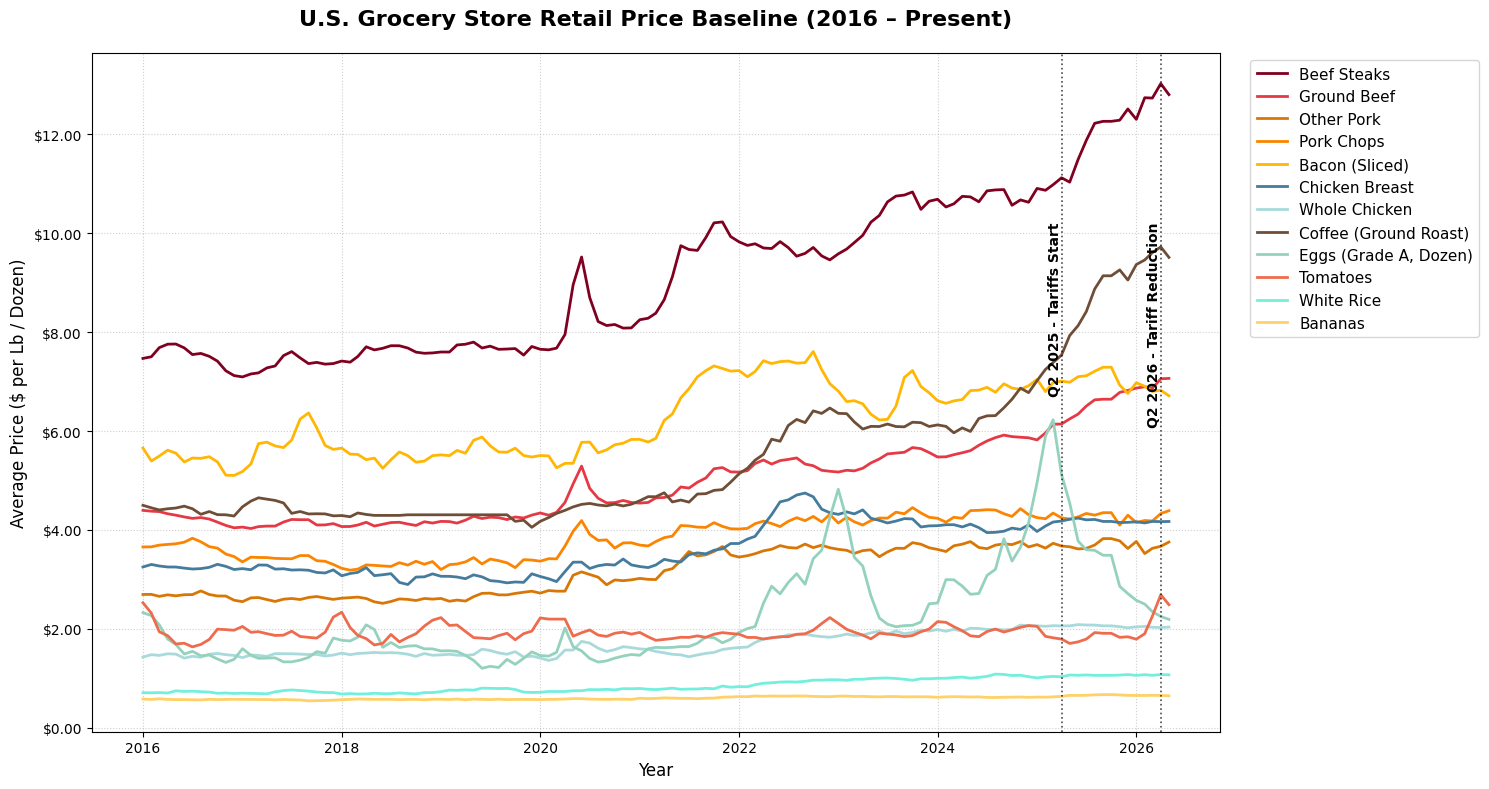

In [6]:
fig, ax = plt.subplots(figsize=(15, 8))

colors = {
    'Beef Steaks': '#800020', 'Ground Beef': '#e63946',          
    'Bacon (Sliced)': '#ffb703', 'Pork Chops': '#fb8500', 'Other Pork': '#d97706', 
    'Chicken Breast': '#457b9d', 'Whole Chicken': '#a8dadc',    
    'Coffee (Ground Roast)': '#6f4e37', 'Eggs (Grade A, Dozen)': '#94d2bd', 
    'Tomatoes': '#ee6c4d', 'White Rice': '#72efdd', 'Bananas': '#ffd166'     
}

events = {
    '2025-04-01': 'Q2 2025 - Tariffs Start',
    '2026-04-01': 'Q2 2026 - Tariff Reduction',
}

for code, name in retail_matrix.items():
    if code in df.columns:
        ax.plot(df.index, df[code], label=name, color=colors[name], linewidth=2)

y = plt.ylim()[1] * 0.75

plt.title('U.S. Grocery Store Retail Price Baseline (2016 – Present)', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Average Price ($ per Lb / Dozen)', fontsize=12)
ax.yaxis.set_major_formatter('${x:,.2f}')
ax.set_xlabel('Year', fontsize=12)
add_event_lines(events, df, y)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Section 2: Commodity Category Pipeline Foundations

## Upstream Sourcing Pressures (PPI), Consumer Anchors (CPI), & Retail Checkout Costs

### Description
This section isolates three core foundational grocery sectors: Meats & Poultry, Coffee Sourcing, and Produce & Stable Grains. By mapping these specific category blocks, the visualizations analyze how upstream commodity cost structures and intermediate wholesale conditions translate into absolute checkout prices. Each sector is plotted utilizing a dual-axis scale to cleanly separate raw physical consumer retail figures from macro indexing parameters, highlighting category-specific pricing dynamics.

---

### Pipeline 1: The Meat & Poultry Market
* **Left Y-Axis (Retail Checkout Price):** Tracks actual grocery store checkout values for luxury cuts (`APU0000FC3101` - Beef Steaks), processed breakfast cuts (`APU0000704111` - Sliced Bacon), and lean high-volume poultry baselines (`APU0000FF1101` - Chicken Breasts).
* **Right Y-Axis (Supply-Chain Indices):** Maps upstream raw input pressures (`WPS022` - PPI: Slaughter Livestock) alongside aggregate urban consumer benchmarks (`CPI_Meat_3MA_Index`).

### Pipeline 2: The Coffee Sourcing Network
* **Left Y-Axis (Retail Checkout Price):** Tracks shelf consumer costs for processed items (`APU0000717311` - 100% Ground Roast Coffee).
* **Right Y-Axis (Supply-Chain Indices):** Contrasts wholesale raw importing and roasting floors (`WPU026301` - PPI: Unroasted Coffee Beans) with final aggregated urban market index trends (`CPI_Coffee_3MA_Index`).

### Pipeline 3: Produce & Agricultural Staples
* **Left Y-Axis (Retail Checkout Price):** Isolates unweighted staple crop items spanning quick-turn produce (`APU0000712311` - Tomatoes; `APU0000711211` - Bananas) and long-shelf carbohydrates (`APU0000701312` - Long-Grain White Rice).
* **Right Y-Axis (Supply-Chain Indices):** Tracks structural milled field pricing (`WPU0213` - PPI: Milled Rice Commodity) against the overarching seasonal field vegetation index (`CPI_FruitVeg_3MA_Index`).

---

### Key Analytical Observations
1. **Transmission Delta Violations:** Note the structural variance in how quickly price increases travel through different food segments. High-velocity sectors like meats display narrow, responsive transmission lag windows, while highly processed or globally shipped items like ground coffee frequently display delayed, elongated lag cycles.
2. **Category Price Ceilings:** Observe how baseline agricultural carbohydrates (White Rice and Bananas) maintain horizontal, inelastic price lines even when their broader category indices experience structural upward drift, highlighting the strict pricing floors of core consumer food security items.

In [7]:
# YoY inflation changes
df['CPI_Meat_YoY_Rate'] = df['CUSR0000SAF112'].pct_change(periods = 12) * 100
df['CPI_Coffee_YoY_Rate'] = df['CUSR0000SEFP01'].pct_change(periods = 12) * 100
df['CPI_FruitVeg_YoY_Rate'] = df['CUSR0000SAF113'].pct_change(periods = 12) * 100

# 3-Month index moving average
df['CPI_Meat_3MA_Index'] = df['CUSR0000SAF112'].rolling(window = 3).mean()
df['CPI_Coffee_3MA_Index'] = df['CUSR0000SEFP01'].rolling(window = 3).mean()
df['CPI_FruitVeg_3MA_Index'] = df['CUSR0000SAF113'].rolling(window = 3).mean()
 
# 3-Month YoY inflation moving average
df['CPI_Meat_YoY_3MA'] = df['CPI_Meat_YoY_Rate'].rolling(window = 3).mean()
df['CPI_Coffee_YoY_3MA'] = df['CPI_Coffee_YoY_Rate'].rolling(window = 3).mean()
df['CPI_FruitVeg_YoY_3MA'] = df['CPI_FruitVeg_YoY_Rate'].rolling(window = 3).mean()

In [8]:
# 12-mo CPI/PPI moving averages
df['CPI_Meat_12MA'] = df['CUSR0000SAF112'].rolling(window = 12).mean()
df['PPI_Meat_12MA'] = df['WPS022'].rolling(window = 12).mean()

df['CPI_Coffee_12MA'] = df['CUSR0000SEFP01'].rolling(window = 12).mean()
df['PPI_Coffee_12MA'] = df['WPU026301'].rolling(window = 12).mean()

df['CPI_FruitVeg_12MA'] = df['CUSR0000SAF113'].rolling(window = 12).mean()
df['PPI_Rice_12MA'] = df['WPU0213'].rolling(window = 12).mean()

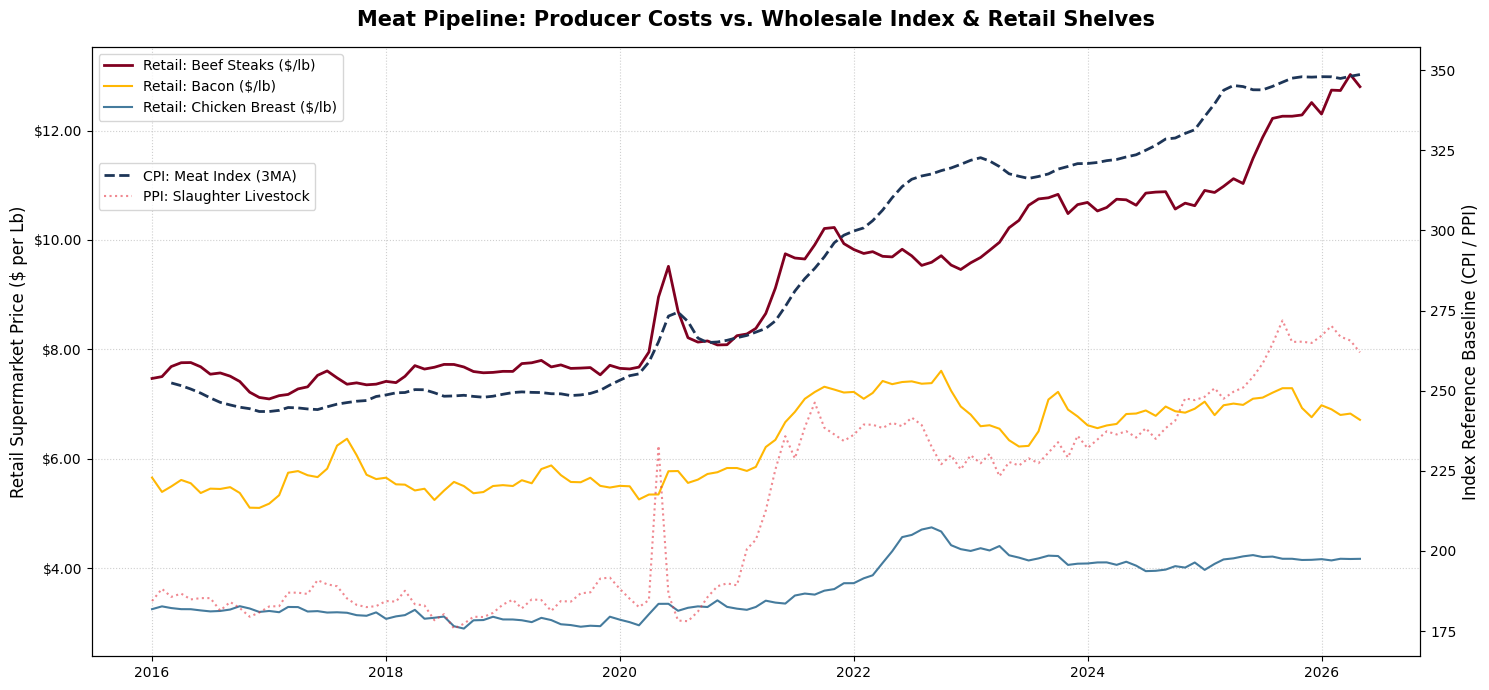

In [9]:
fig, ax1 = plt.subplots(figsize=(15, 7))

# consumer retail prices
ax1.plot(df.index, df['APU0000FC3101'], label='Retail: Beef Steaks ($/lb)', color='#800020', linewidth=2)
ax1.plot(df.index, df['APU0000704111'], label='Retail: Bacon ($/lb)', color='#ffb703', linewidth=1.5)
ax1.plot(df.index, df['APU0000FF1101'], label='Retail: Chicken Breast ($/lb)', color='#457b9d', linewidth=1.5)
ax1.set_ylabel('Retail Supermarket Price ($ per Lb)', fontsize=12)
ax1.yaxis.set_major_formatter('${x:,.2f}')
ax1.legend(loc='upper left', bbox_to_anchor=(0, 1))

# macronomic indices
ax2 = ax1.twinx()
ax2.plot(df.index, df['CPI_Meat_3MA_Index'], label='CPI: Meat Index (3MA)', color='#1d3557', linestyle='--', linewidth=2)
ax2.plot(df.index, df['WPS022'], label='PPI: Slaughter Livestock', color='#e63946', linestyle=':', alpha=0.6)
ax2.set_ylabel('Index Reference Baseline (CPI / PPI)', fontsize=12)
ax2.legend(loc='upper left', bbox_to_anchor=(0, 0.82))

plt.title('Meat Pipeline: Producer Costs vs. Wholesale Index & Retail Shelves', fontsize=15, fontweight='bold', pad=15)
ax1.grid(True, linestyle=':', alpha=0.6)
fig.tight_layout()
plt.show()

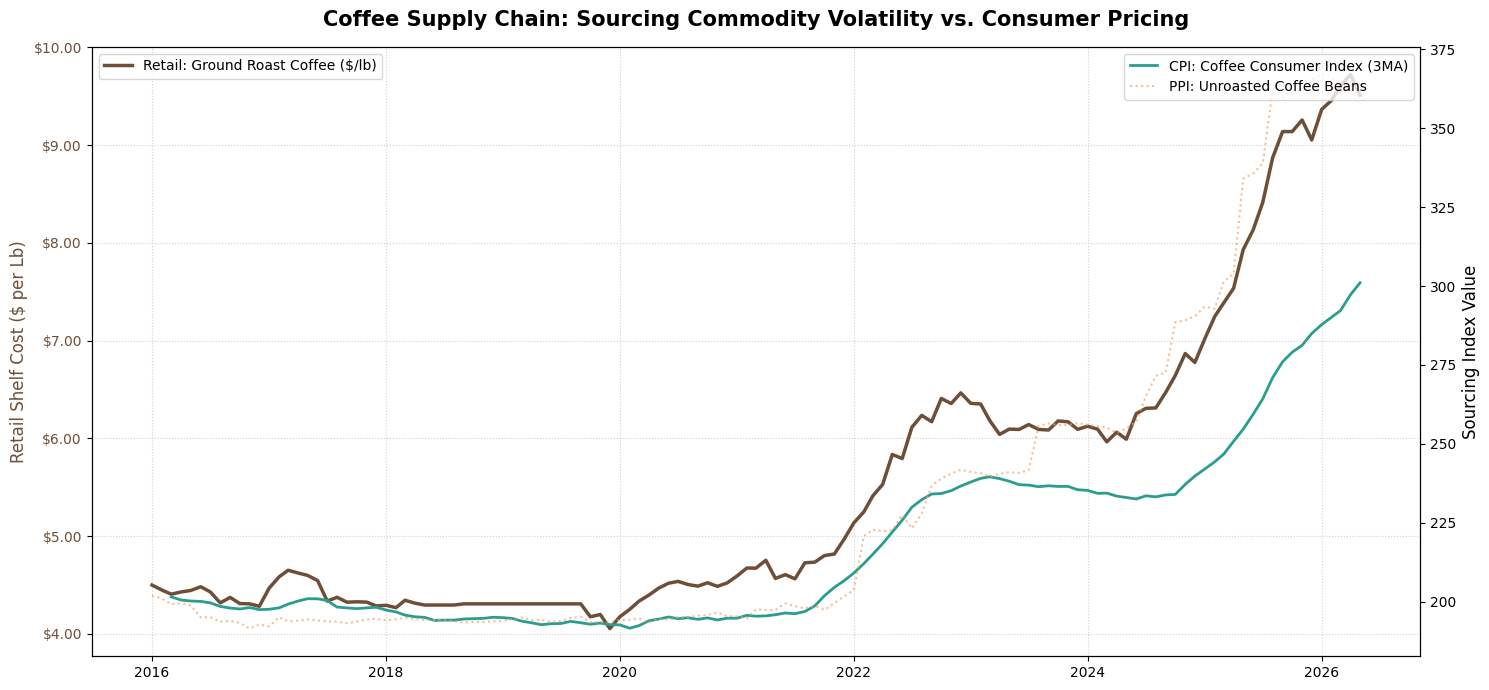

In [10]:
fig, ax1 = plt.subplots(figsize=(15, 7))

# retail pricing
ax1.plot(df.index, df['APU0000717311'], label='Retail: Ground Roast Coffee ($/lb)', color='#6f4e37', linewidth=2.5)
ax1.set_ylabel('Retail Shelf Cost ($ per Lb)', color='#6f4e37', fontsize=12)
ax1.yaxis.set_major_formatter('${x:,.2f}')
ax1.tick_params(axis='y', labelcolor='#6f4e37')
ax1.legend(loc='upper left')

# producer indices
ax2 = ax1.twinx()
ax2.plot(df.index, df['CPI_Coffee_3MA_Index'], label='CPI: Coffee Consumer Index (3MA)', color='#2a9d8f', linewidth=2)
ax2.plot(df.index, df['WPU026301'], label='PPI: Unroasted Coffee Beans', color='#f4a261', linestyle=':', alpha=0.7)
ax2.set_ylabel('Sourcing Index Value', fontsize=12)
ax2.legend(loc='upper right')

plt.title('Coffee Supply Chain: Sourcing Commodity Volatility vs. Consumer Pricing', fontsize=15, fontweight='bold', pad=15)
ax1.grid(True, linestyle=':', alpha=0.6)
fig.tight_layout()
plt.show()

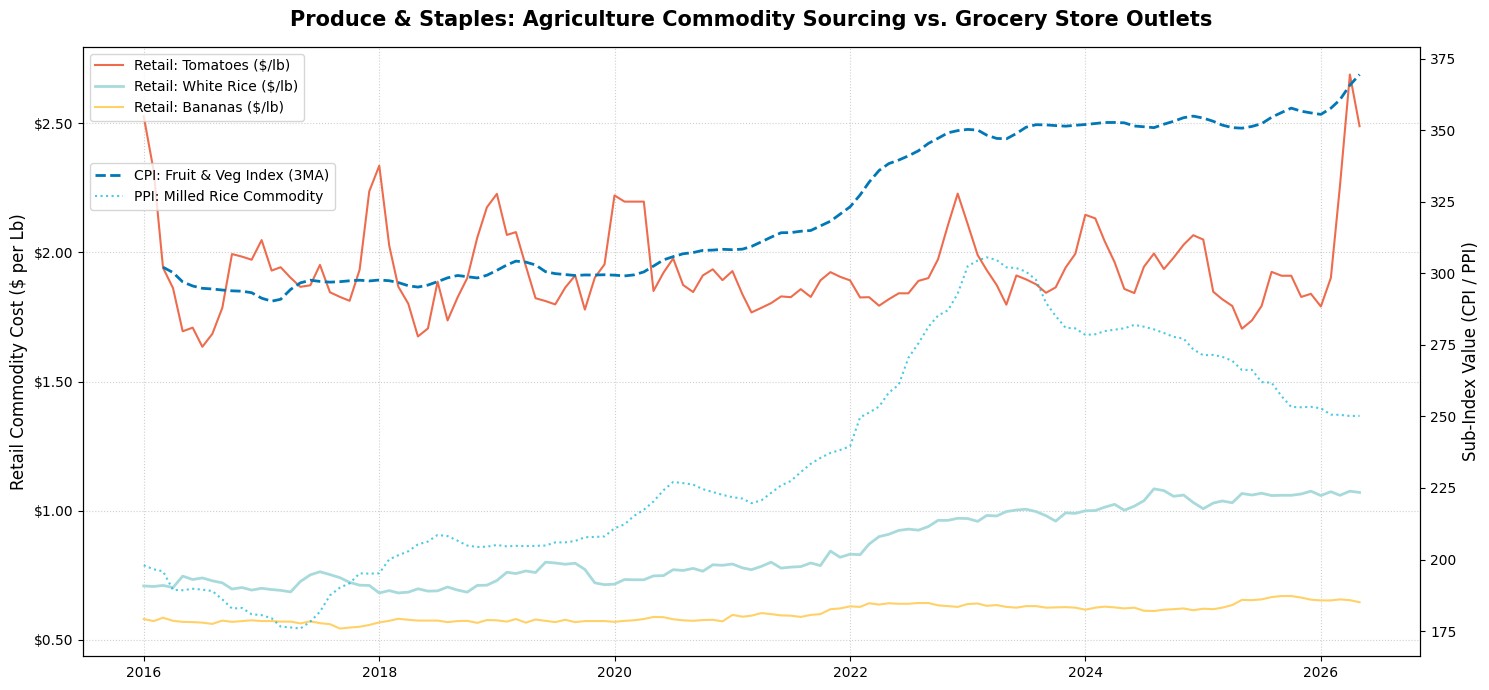

In [11]:
fig, ax1 = plt.subplots(figsize=(15, 7))

# prices
ax1.plot(df.index, df['APU0000712311'], label='Retail: Tomatoes ($/lb)', color='#ee6c4d', linewidth=1.5)
ax1.plot(df.index, df['APU0000701312'], label='Retail: White Rice ($/lb)', color='#a8dadc', linewidth=2)
ax1.plot(df.index, df['APU0000711211'], label='Retail: Bananas ($/lb)', color='#ffd166', linewidth=1.5)
ax1.set_ylabel('Retail Commodity Cost ($ per Lb)', fontsize=12)
ax1.yaxis.set_major_formatter('${x:,.2f}')
ax1.legend(loc='upper left', bbox_to_anchor=(0, 1))

# macronomic moving averages
ax2 = ax1.twinx()
ax2.plot(df.index, df['CPI_FruitVeg_3MA_Index'], label='CPI: Fruit & Veg Index (3MA)', color='#0077b6', linestyle='--', linewidth=2)
ax2.plot(df.index, df['WPU0213'], label='PPI: Milled Rice Commodity', color='#00b4d8', linestyle=':', alpha=0.7)
ax2.set_ylabel('Sub-Index Value (CPI / PPI)', fontsize=12)
ax2.legend(loc='upper left', bbox_to_anchor=(0, 0.82))

plt.title('Produce & Staples: Agriculture Commodity Sourcing vs. Grocery Store Outlets', fontsize=15, fontweight='bold', pad=15)
ax1.grid(True, linestyle=':', alpha=0.6)
fig.tight_layout()
plt.show()

# Section 3: Inflation Velocity & Acceleration Analysis

## Year-over-Year (YoY) Changing Trends vs. Real-World Market Value Impact

### Description
This section moves away from absolute index values to chart the real-time velocity of price changes. By plotting your engineered Year-over-Year (YoY) calculations alongside a smoothed 3-Month Moving Average (3MA) rate line, this visualization highlights the exact moments when grocery market inflation began to actively accelerate, flatten, or clear turning points toward disinflation.

### Visual Architecture & Components
- **Primary Scale (Left Y-Axis):** Retains the unweighted retail grocery dollar footprint (`APU0000FC3101` - Beef Steaks) to show the tangible, real-world price points that remain behind as an inflation wave passes.
- **Velocity Tracking Matrix (Right Y-Axis):** 
  - **Raw Annual Pace:** `CPI_Meat_YoY_Rate` — The absolute annual change over a rolling 12-month window.
  - **Smoothed Momentum Trend:** `CPI_Meat_YoY_3MA` — A 3-Month Moving Average of the YoY calculation used to separate structural momentum directions from single-month statistical noise.

---

### Analytical Insights to Note
1. **The Post-Peak Plateau Effect:** This chart visualizes an essential concept in macroeconomic tracking: *declining inflation velocity does not equal declining supermarket checkout prices*. Even as the right-hand percentage rate curve trends down toward historical averages, the left-hand dollar line often forms a permanent, elevated plateau.
2. **Velocity Inflection Flags:** Watch for moments where the bold 3MA trendline cleanly cuts through the lighter, jagged raw YoY lines. These statistical intersections flag short-term turning points across the wider supply network weeks before they become obvious in the absolute dollar price metrics.

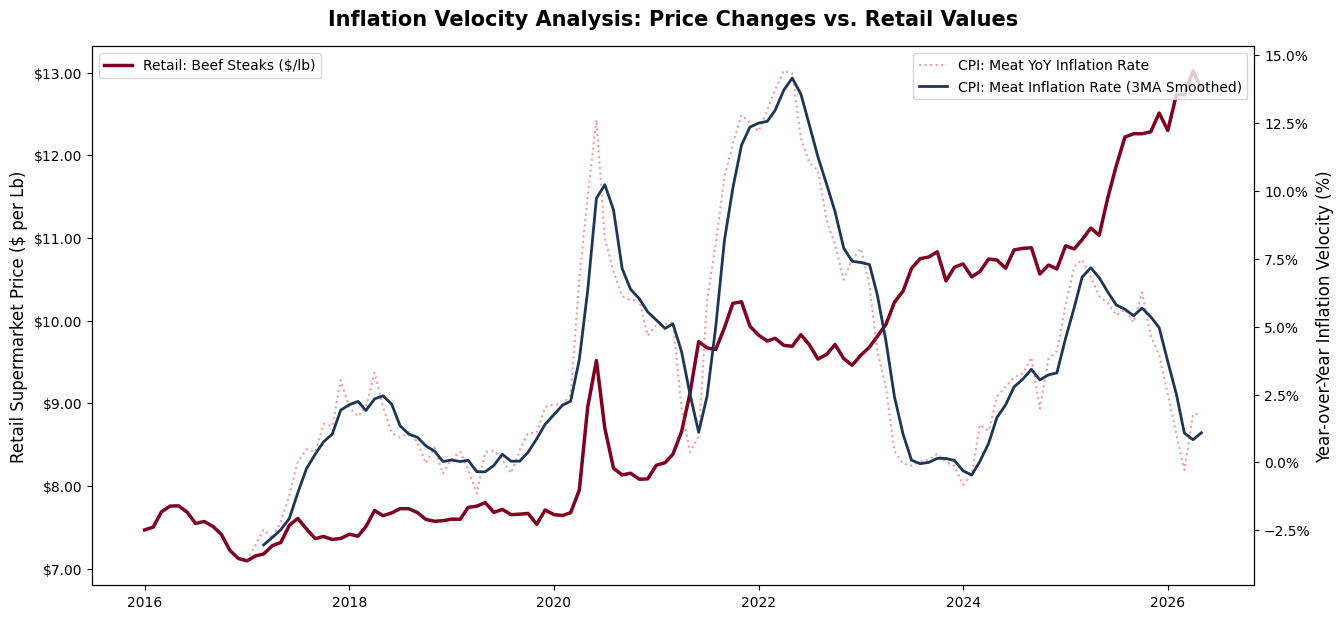

In [12]:
fig, ax1 = plt.subplots(figsize=(15, 7))

ax1.plot(df.index, df['APU0000FC3101'], label='Retail: Beef Steaks ($/lb)', color='#800020', linewidth=2.5)
ax1.set_ylabel('Retail Supermarket Price ($ per Lb)', fontsize=12)
ax1.yaxis.set_major_formatter('${x:,.2f}')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(df.index, df['CPI_Meat_YoY_Rate'], label='CPI: Meat YoY Inflation Rate', color='#e63946', linestyle=':', alpha=0.5)
ax2.plot(df.index, df['CPI_Meat_YoY_3MA'], label='CPI: Meat Inflation Rate (3MA Smoothed)', color='#1d3557', linewidth=2)

ax2.set_ylabel('Year-over-Year Inflation Velocity (%)', fontsize=12)
ax2.yaxis.set_major_formatter('{x:.1f}%') 
ax2.legend(loc='upper right')

plt.title('Inflation Velocity Analysis: Price Changes vs. Retail Values', fontsize=15, fontweight='bold', pad=15)
plt.show()

# Section 4: Macroeconomic Synthesis & Structural Conclusions

## Key Supply Chain Takeaways (2016 – Present)

Having evaluated the comprehensive retail baseline, the localized category pipelines, and the underlying momentum of inflation velocity, several distinct structural patterns emerge across the U.S. grocery supply chain:

### 1. The Sourcing Transmission Sequence
Across all core food families, upstream producer shocks (PPI spikes) function as definitive leading indicators for consumer price index (CPI) inflection points.
* **The Sourcing Lag:** Wholesale raw material volatility typically requires a **30-to-90-day window** to propagate through food processing channels, cold-chain logistics, and inventory management lifecycles before physically manifesting at retail supermarket checkout counters.
* **Asymmetrical Price Transmission:** Historically, grocery prices demonstrate "sticky downward" behavior. While upstream PPI commodity relief hits the supply network relatively quickly, retail dollar metrics ($/lb) often plateau at elevated historical ceilings rather than reversing symmetrically.

### 2. Elasticity Variance Across Food Families
The data reveals stark differences in how premium agricultural items react to inflationary pressures compared to inelastic consumer staple goods:
* **High-Elasticity Proteins (Meats & Poultry):** Premium meat lines (e.g., Beef Steaks) show immediate vulnerability to inventory and sourcing changes. Price adjustments happen rapidly on the shelves because consumer demand ceilings dynamically adapt to inflationary stress.
* **Inelastic Baseline Staples (White Rice & Bananas):** Core carbohydrates act as strict structural anchors. Even when macro category sub-indices experience substantial upward trends, these high-volume basic commodities stay comparatively flat to secure essential household food access.

### 3. Velocity Signaling vs. Structural Plateaus
Analyzing inflation through a velocity framework highlights a crucial macroeconomic distinction for consumers and policy analysts alike:
* **Disinflation $\neq$ Deflation:** A sharp downward correction in the **3-Month YoY Inflation Moving Average** signifies an inflation *deceleration* (prices rising at a slower pace), not a price drop. 
* **Permanent Baseline Shifts:** As the percentage velocity maps back toward historical ranges, the absolute physical retail line ($/lb) stabilizes on an elevated plateau. This shows that the post-2022 macroeconomic shock has permanently reset the baseline cost structure of the domestic grocery checkout counter.

# Conclusions and Observations

1. Tariffs shoved one up the alley.
2. Formal review in progress.

#### Update Schedule

- ***Food Prices (Retail) - Jul 15, 2026***

    **Beef & Pork Matrix**
    1. `APU0000FC3101`: **Beef Steaks**
    2. `APU0000FC1101`: **Ground Beef**
    3. `APU0000FD3101`: **Pork Chops**
    4. `APU0000FD4101`: **Other Pork**
    5. `APU0000704111`: **Sliced Bacon**

    **Poultry & Staples**

    6. `APU0000FF1101`: **Chicken Breast**
    7. `APU0000706111`: **Whole Chicken**
    8. `APU0000708111`: **Grade A Large Eggs**

    **Coffee & Grocery Staples**

    9. `APU0000717311`: **Ground Roast Coffee**
    10. `APU0000701312`: **White Long-Grain Rice**

    **Produce**
    
    11. `APU0000712311`: **Field-Grown Tomatoes**
    12. `APU0000711211`: **Bananas**

- ***Macro Consumer Price Indices (CPI-U) - Jul 15, 2026***

    13. `CUSR0000SAF112`: **Meats, Poultry, Fish, and Eggs (Monthly Average Index)**
    14. `CUSR0000SEFP01`: **Coffee (Monthly Average Index)**
    15. `CUSR0000SAF113`: **Fruits and Vegetables (Monthly Average Index)**

- ***Wholesale Producer Price Commodities (PPI) - Jul 14, 2026***

    16. `WPS022`: **Processed Foods and Feeds: Meats, Poultry, and Fish**
    17. `WPU026301`: **Processed Foods and Feeds: Coffee (Whole Bean, Ground, Instant)**
    18. `WPU0213`: **Processed Foods and Feeds: Milled Rice and Byproducts**

#### Data Changelog / Notes


#### ***Review and analysis publishing on Friday, -----, 2026, at 1:30 P.M. Pacific Time.***